In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.models import Model

In [23]:
from tensorflow.keras.datasets import cifar10

(x_train, _), (_, _) = cifar10.load_data()

# Step 1: pick image
content_image = x_train[0]

# Step 2: preprocess it (THIS IS MUST)
content_image = preprocess_img(content_image)

print(content_image.shape)

(1, 224, 224, 3)


In [24]:
def preprocess_img(img):
    img = tf.image.resize(img, (224, 224))
    img = img.numpy()              
    img = img.copy()               
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

In [25]:
from tensorflow.keras.preprocessing import image

style_path = "/kaggle/input/datasets/aryanmittal07/image1/untitled.jpg"

def load_style(path):
    img = image.load_img(path, target_size=(224, 224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

style_image = load_style(style_path)

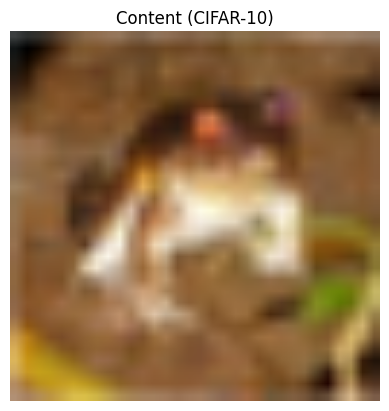

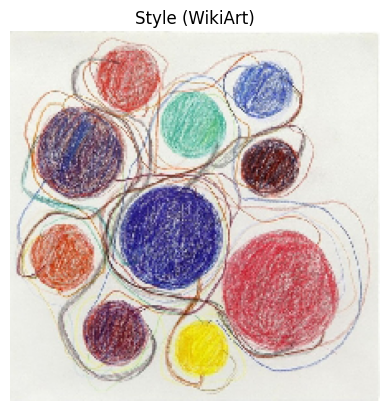

In [26]:
def deprocess_img(x):
    x = x.numpy() if isinstance(x, tf.Tensor) else x
    
    if len(x.shape) == 4:
        x = x[0]
    
    x = x.astype(np.float32)   
    
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    
    x = x[:, :, ::-1]
    return np.clip(x, 0, 255).astype('uint8')
plt.imshow(deprocess_img(content_image))
plt.title("Content (CIFAR-10)")
plt.axis("off")
plt.show()

plt.imshow(deprocess_img(style_image))
plt.title("Style (WikiArt)")
plt.axis("off")
plt.show()

In [27]:
vgg = VGG19(weights='imagenet', include_top=False)

for layer in vgg.layers:
    layer.trainable = False

In [28]:
content_layer = 'block5_conv2'

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [29]:
outputs = [vgg.get_layer(content_layer).output]

for layer in style_layers:
    outputs.append(vgg.get_layer(layer).output)

model = Model(inputs=vgg.input, outputs=outputs)

In [30]:
def content_loss(content, generated):
    return tf.reduce_mean(tf.square(content - generated))

def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.matmul(x, x, transpose_a=True)

def style_loss(style, generated):
    S = gram_matrix(style)
    G = gram_matrix(generated)
    return tf.reduce_mean(tf.square(S - G))

In [31]:
def total_loss(content_outputs, style_outputs, generated_outputs, alpha=1e4, beta=1e-2):
    
    c_loss = content_loss(content_outputs[0], generated_outputs[0])
    
    s_loss = 0
    for i in range(len(style_layers)):
        s_loss += style_loss(style_outputs[i], generated_outputs[i])
    
    s_loss /= len(style_layers)
    
    return alpha * c_loss + beta * s_loss

In [32]:
content_features = model(content_image)
style_features = model(style_image)

In [33]:
generated_image = tf.Variable(content_image, dtype=tf.float32)

In [34]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5.0)

In [35]:
@tf.function
def train_step(generated_image):
    with tf.GradientTape() as tape:
        gen_outputs = model(generated_image)
        loss = total_loss(content_features, style_features, gen_outputs)
    
    grads = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grads, generated_image)])
    
    return loss

In [36]:
epochs = 10
steps_per_epoch = 100

for epoch in range(epochs):
    for step in range(steps_per_epoch):
        loss = train_step(generated_image)
    
    print(f"Epoch {epoch+1}, Loss: {loss.numpy()}")

Epoch 1, Loss: 17558718644224.0
Epoch 2, Loss: 6919431389184.0
Epoch 3, Loss: 3043575726080.0
Epoch 4, Loss: 1800596094976.0
Epoch 5, Loss: 1304573509632.0
Epoch 6, Loss: 1051659534336.0
Epoch 7, Loss: 871559004160.0
Epoch 8, Loss: 769544749056.0
Epoch 9, Loss: 711740882944.0
Epoch 10, Loss: 680398749696.0


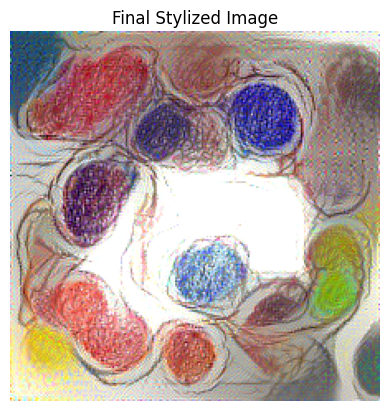

In [37]:
result = deprocess_img(generated_image.numpy())

plt.imshow(result)
plt.title("Final Stylized Image")
plt.axis("off")
plt.show()